# 光谱处理：Superfit / NGSF 模板拟合

本 notebook 仿照 `spectral_processing.ipynb` 的数据流，但用 **NGSF (Next Generation SuperFit)** 进行超新星光谱模板拟合。

流程：

1. 读取 `data/<target>/spectrum/spectrum_*.dat` 光谱。
2. 调用 NGSF/Superfit，对 SN 模板 + 宿主星系模板进行联合拟合。
3. 展示最佳拟合结果表和 NGSF 生成的叠加图。
4. 用 Superfit 的类型和红移结果估算一条典型谱线的膨胀速度。

注意：NGSF 的 PyPI 包内部会在 import 时读取 `sys.argv[1]`，所以这里通过子进程传入 JSON 参数来运行，避免污染 Jupyter kernel 状态。

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import os
import subprocess
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from IPython.display import Image, display

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.wiserep import plot_spectra


def check_ngsf_install():
    import importlib.util

    missing = [name for name in ("NGSF", "extinction", "PyAstronomy") if importlib.util.find_spec(name) is None]
    if missing:
        raise ImportError(
            "缺少 NGSF 依赖: "
            + ", ".join(missing)
            + "\n建议在项目根目录运行：\n"
            + "conda run -n astro_env python -m pip install NGSF\n"
            + "conda run -n astro_env python -m pip install --force-reinstall 'numpy==1.23.5' 'quantities<0.16'"
        )

    import NGSF

    ngsf_path = Path(NGSF.__path__[0])
    bank_dir = ngsf_path / "bank"
    if not (bank_dir / "binnings" / "10A").exists():
        raise FileNotFoundError(
            f"NGSF 已安装，但模板库不存在: {bank_dir}\n"
            "请下载 https://www.wiserep.org/sites/default/files/supyfit_bank.zip ，"
            "解压后把其中的 bank/ 放到上面的 NGSF 包目录。"
        )
    return ngsf_path, bank_dir


ngsf_path, bank_dir = check_ngsf_install()
print(f"NGSF package: {ngsf_path}")
print(f"NGSF bank:    {bank_dir}")
print(f"Python:       {sys.executable}")

NGSF package: /Users/ao/miniforge3/envs/astro_env/lib/python3.10/site-packages/NGSF
NGSF bank:    /Users/ao/miniforge3/envs/astro_env/lib/python3.10/site-packages/NGSF/bank
Python:       /Users/ao/miniforge3/envs/astro_env/bin/python


## 1. 加载并可视化光谱

修改 `target_name`、`host_galaxy_z` 和 `spectrum_index` 即可切换目标和光谱。`host_galaxy_z = None` 时会改用红移网格搜索，但运行会更慢，且不能遮蔽宿主星系窄线。

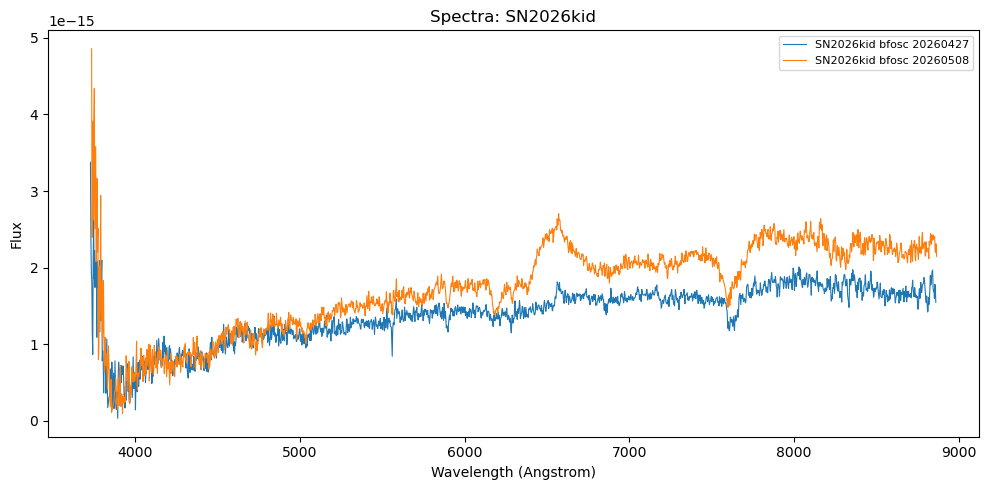

Target:        SN2026kid
Spectrum file: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/data/SN2026kid/SN2026kid_bfosc_20260508.txt
Points:        1854
Range:         3735-8864 A


In [ ]:
target_name = "SN2026kid"
host_galaxy_z = None  # 已知宿主红移；未知时设为 None
spectrum_index = 2        # 若同一目标有多条光谱，改这个索引

SPECTRUM_DIR = PROJECT_ROOT / "data" / target_name
spectrum_files = sorted(SPECTRUM_DIR.glob("*.txt"))
if not spectrum_files:
    raise FileNotFoundError(f"No *.txt files found in {SPECTRUM_DIR}")

plot_spectra(spectrum_files, target_name, jupyter=True)

spec_file = spectrum_files[spectrum_index]
data = np.loadtxt(spec_file)
wave_obs = data[:, 0]
flux_obs = data[:, 1]

print(f"Target:        {target_name}")
print(f"Spectrum file: {spec_file}")
print(f"Points:        {len(wave_obs)}")
print(f"Range:         {wave_obs.min():.0f}-{wave_obs.max():.0f} A")

## 2. 配置并运行 Superfit

默认用较宽的常见 SN 模板集合、30 Å 分辨率和较粗的消光网格，速度比较友好。若想更精细，可以把 `resolution` 改成 `10`，或把 `alam_interval` 改小。

In [23]:
superfit_dir = PROJECT_ROOT / "data" / target_name / "superfit"
superfit_dir.mkdir(parents=True, exist_ok=True)

# 常见 SN 类型；如果已经知道大类，可以删掉无关类型来加速。
sn_template_types = [
    "Ia-norm", "Ia 91T-like", "Ia 91bg-like", "Ia-pec",
    "II", "IIn", "IIb", "Ib", "Ic", "Ic-BL",
    "SLSN-I", "SLSN-II", "TDE H", "TDE H+He",
]
galaxy_template_types = ["E", "S0", "Sa", "Sb", "Sc"]

use_exact_z = host_galaxy_z is not None

ngsf_params = {
    "object_to_fit": str(spec_file.resolve()),
    "use_exact_z": 1 if use_exact_z else 0,
    "z_exact": float(host_galaxy_z or 0.0),
    "z_range_begin": 0.0,
    "z_range_end": 0.08,
    "z_int": 0.005,
    "resolution": 30,
    "temp_sn_tr": sn_template_types,
    "temp_gal_tr": galaxy_template_types,
    "lower_lam": 3800,
    "upper_lam": 8500,
    "error_spectrum": "sg",
    "saving_results_path": str(superfit_dir.resolve()) + "/",
    "show_plot": 0,
    "show_plot_png": True,
    "how_many_plots": 5,
    "mask_galaxy_lines": 1 if use_exact_z else 0,
    "mask_telluric": 1,
    "minimum_overlap": 0.6,
    "epoch_high": 0,
    "epoch_low": 0,
    "Alam_high": 1.5,
    "Alam_low": -1.5,
    "Alam_interval": 0.5,
}

runner_code = r'''
import json
import sys
import matplotlib
matplotlib.use("Agg")

params = json.loads(sys.argv[1])
sys.argv = ["ngsf_notebook", json.dumps(params)]

from NGSF.sf_class import Superfit

fit = Superfit()
fit.superfit()
print(fit.results_path)
'''

print("Running NGSF/Superfit...")
completed = subprocess.run(
    [sys.executable, "-c", runner_code, json.dumps(ngsf_params)],
    cwd=str(PROJECT_ROOT),
    text=True,
    capture_output=True,
)

print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("NGSF/Superfit failed")

results_path = superfit_dir / f"{spec_file.stem}.csv"
if not results_path.exists():
    raise FileNotFoundError(f"Expected results CSV not found: {results_path}")

print(f"Results CSV: {results_path}")

Running NGSF/Superfit...
Running optimization for spectrum file: SN2026kid_bfosc_20260508 with resolution = 30 Å
NGSF started
Runtime:  7.21s 
/Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/data/SN2026kid/superfit/SN2026kid_bfosc_20260508.csv

Results CSV: /Users/ao/THU/astronomy/Observe_astronomy/hw/p2/sn-pipline/data/SN2026kid/superfit/SN2026kid_bfosc_20260508.csv


## 3. 查看拟合结果

NGSF 的结果按 `CHI2/dof2` 排序输出。这里同时给出 SN 类型、模板名、相位、红移、消光参数和 SN/宿主贡献比例。

In [24]:
results = pd.read_csv(results_path)

cols = [
    "SN", "GALAXY", "Z", "A_v", "Phase", "Band",
    "Frac(SN)", "Frac(gal)", "CHI2/dof", "CHI2/dof2",
]
display(results[cols].head(10))

best = results.iloc[0]
superfit_template = str(best["SN"])
superfit_type = superfit_template.split("/")[0]
superfit_z = float(best["Z"])
superfit_phase = best.get("Phase", np.nan)

print("-" * 50)
print(f"Best Superfit type:     {superfit_type}")
print(f"Best template:          {superfit_template}")
print(f"Best redshift:          z = {superfit_z:.5f}")
print(f"Template phase:         {superfit_phase}")
print(f"Host template:          {best['GALAXY']}")
print(f"SN fraction:            {100 * best['Frac(SN)']:.1f}%")
print(f"Reduced chi2 proxy:     {best['CHI2/dof2']:.4g}")
print("-" * 50)

,SN,GALAXY,Z,A_v,Phase,Band,Frac(SN),Frac(gal),CHI2/dof,CHI2/dof2
0,II/2002hh/LRIS phase-band : 8.0V,S0,0.00,1.5,8.00,V,0.172633,0.827367,1.046688,0.006886
1,II/2002hh/LRIS phase-band : 5.0V,S0,0.00,1.5,5.00,V,0.169603,0.830397,1.179643,0.007761
2,II/2002hh/ESI phase-band : 3.0V,S0,0.00,1.5,3.00,V,0.147926,0.852074,1.232313,0.008441
3,II/2002hh/KAST phase-band : -1.0V,S0,0.00,1.5,-1.00,V,0.182041,0.817959,1.374966,0.009046
4,II/2002hh/KAST phase-band : 39.0V,E,0.00,1.0,39.00,V,0.139418,0.860583,1.376310,0.009055
5,Ib/2008D/LRIS phase-band : 46.67B,Sa,0.08,-1.5,46.67,B,0.369853,0.630147,1.844496,0.012135
6,TDE H+He/2018dyb/EFOSC2-NTT phase-band : 199.3B,S0,0.07,-1.5,199.30,B,0.944497,0.055503,1.875277,0.012337


--------------------------------------------------
Best Superfit type:     II
Best template:          II/2002hh/LRIS phase-band : 8.0V
Best redshift:          z = 0.00000
Template phase:         8.0
Host template:          S0
SN fraction:            17.3%
Reduced chi2 proxy:     0.006886
--------------------------------------------------


## 4. 显示 Superfit 叠加图

NGSF 会在 `data/<target>/superfit/` 中保存前几名拟合的 PNG。红线是输入光谱，绿线是 SN+宿主星系模板组合。

SN2026kid_bfosc_20260508_0.png


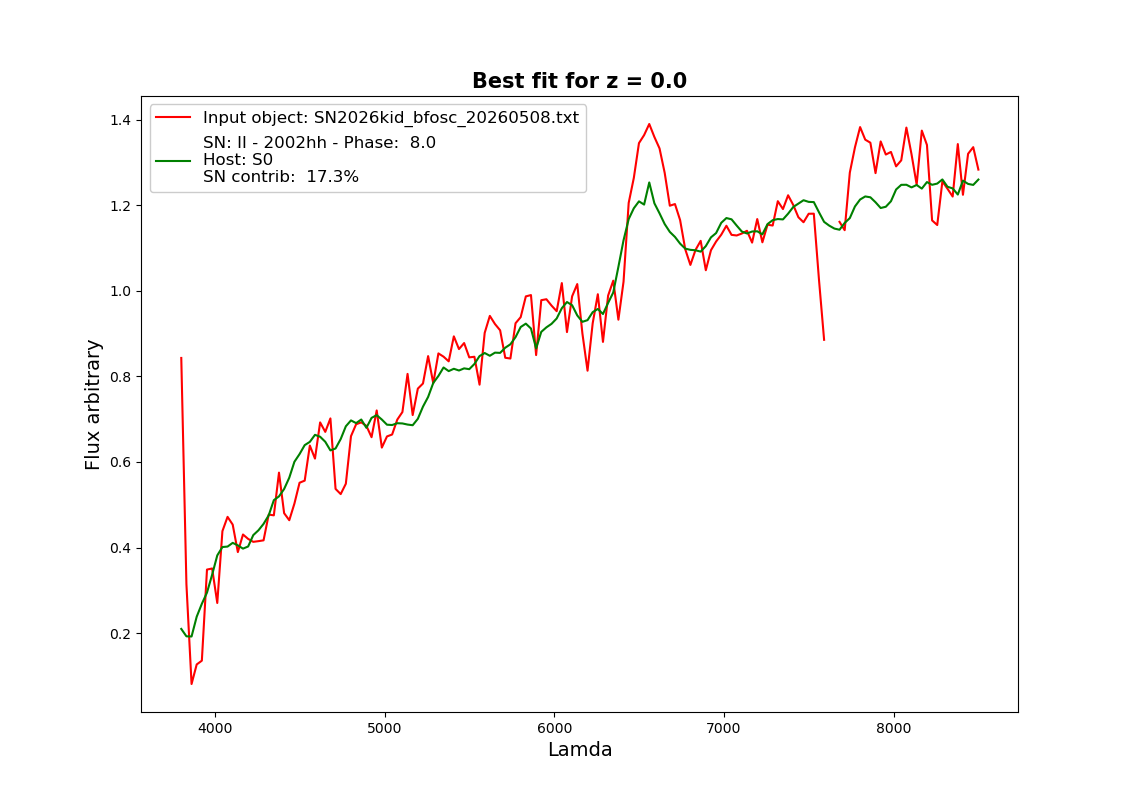

SN2026kid_bfosc_20260508_1.png


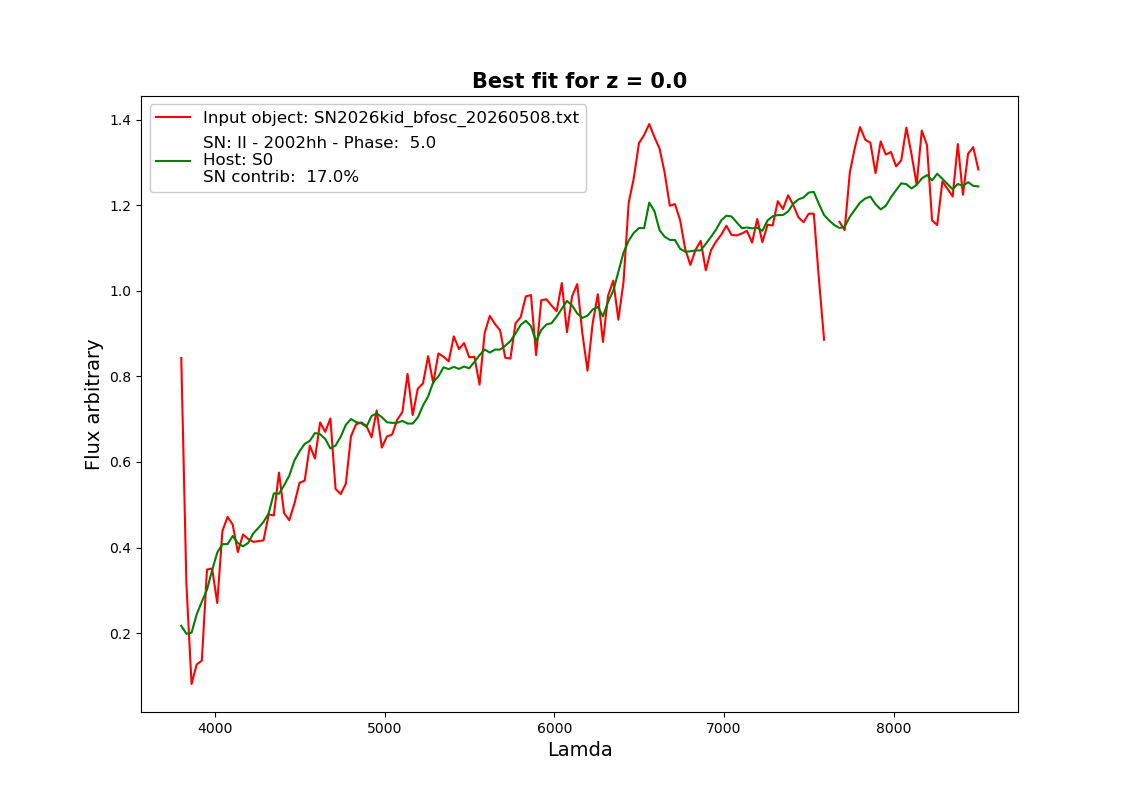

SN2026kid_bfosc_20260508_2.png


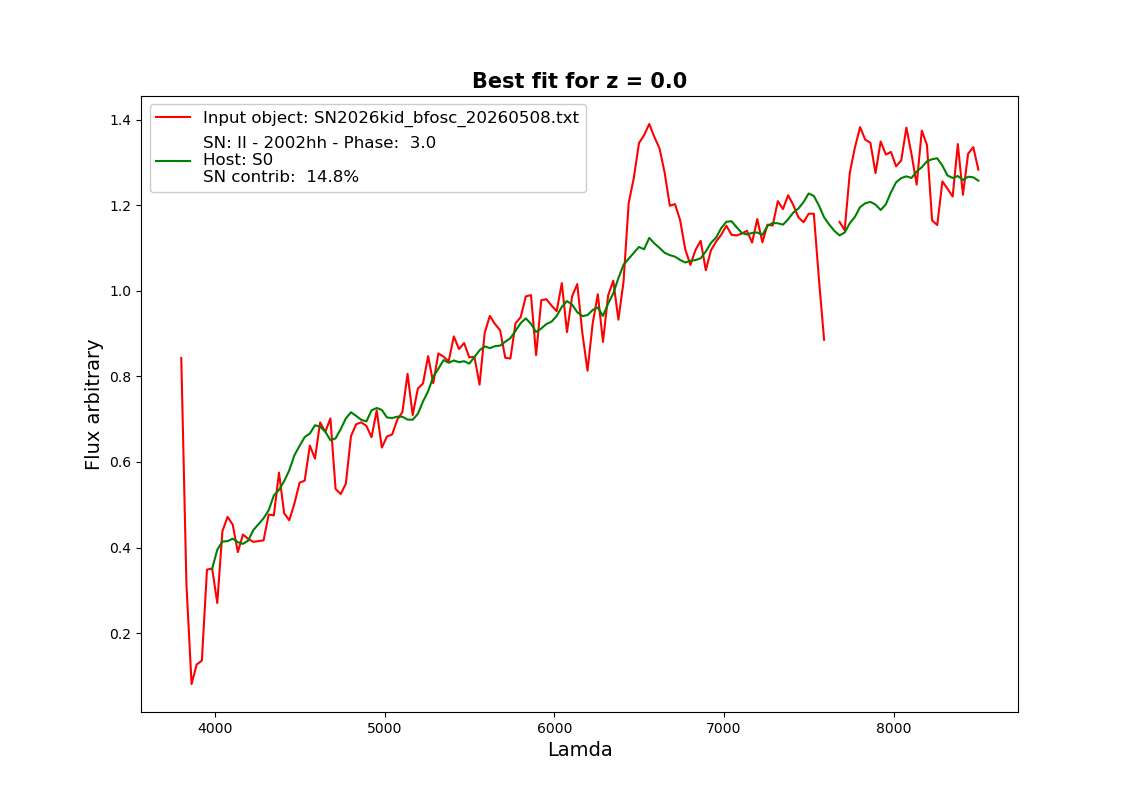

SN2026kid_bfosc_20260508_3.png


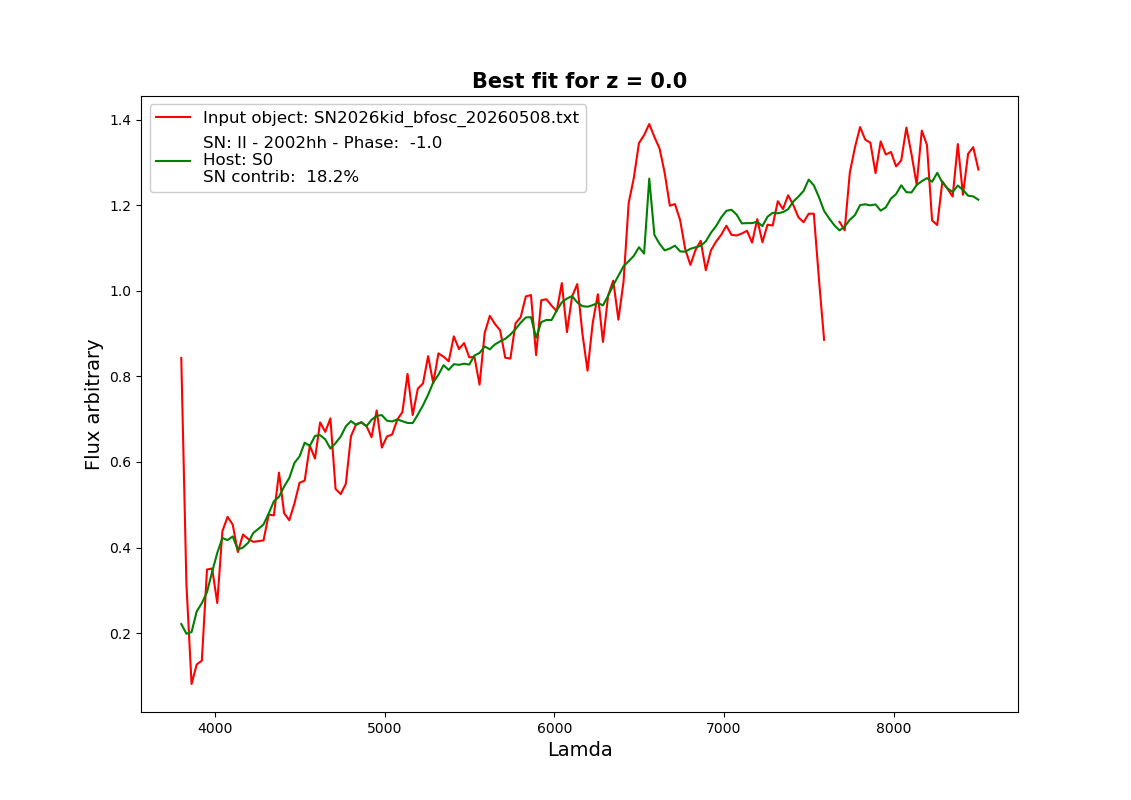

SN2026kid_bfosc_20260508_4.png


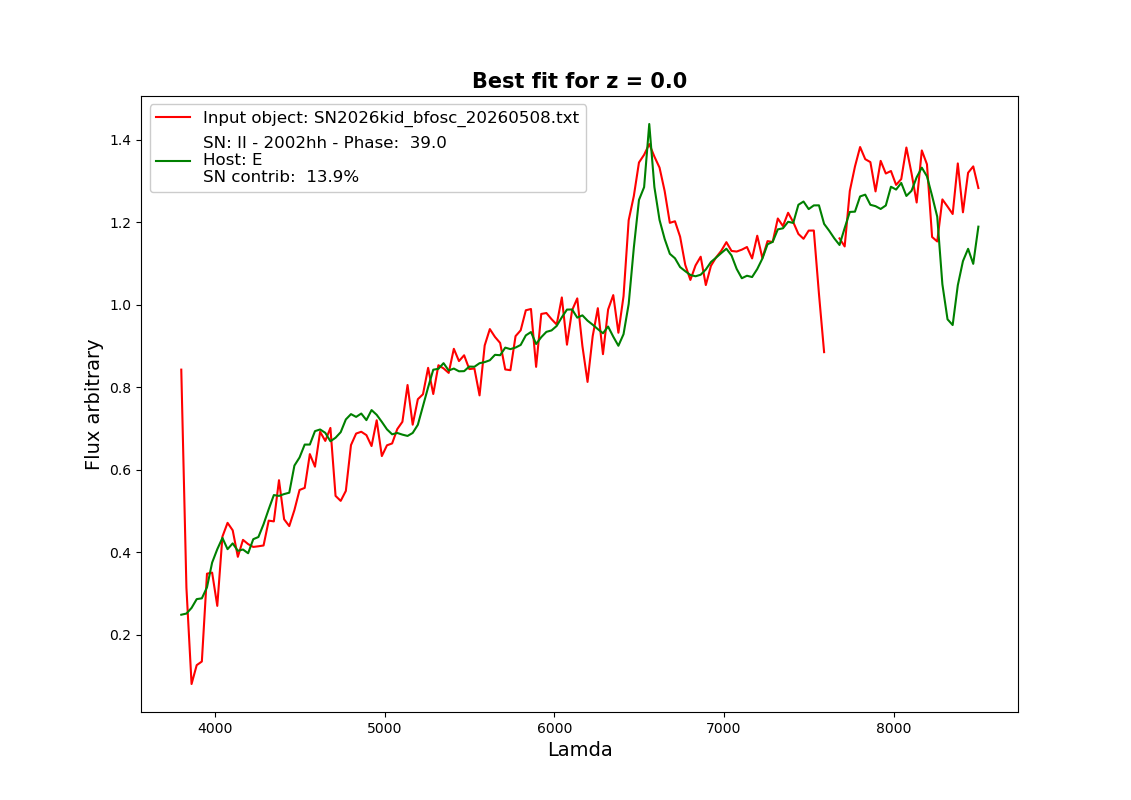

In [25]:
fit_plots = sorted(superfit_dir.glob(f"{spec_file.stem}_*.png"))
if not fit_plots:
    print(f"No NGSF PNG plots found in {superfit_dir}")
else:
    for plot_path in fit_plots[: int(ngsf_params["how_many_plots"])]:
        print(plot_path.name)
        display(Image(filename=str(plot_path)))

## 5. 膨胀速度估算

沿用 DASH notebook 的做法：根据 Superfit 最佳类型选择一条典型谱线，在去红移后的蓝侧搜索吸收谷。这个估计只适合快速检查，最终速度建议人工确认线识别和吸收谷范围。

Spectrum file: SN2026kid_bfosc_20260508.txt
--------------------------------------------------
Superfit type: II
Redshift:      z = 0.00000
Line:          Halpha rest lambda = 6562.8 A
Abs. minimum:  6189.5 A
v_exp:         17054 km/s
--------------------------------------------------


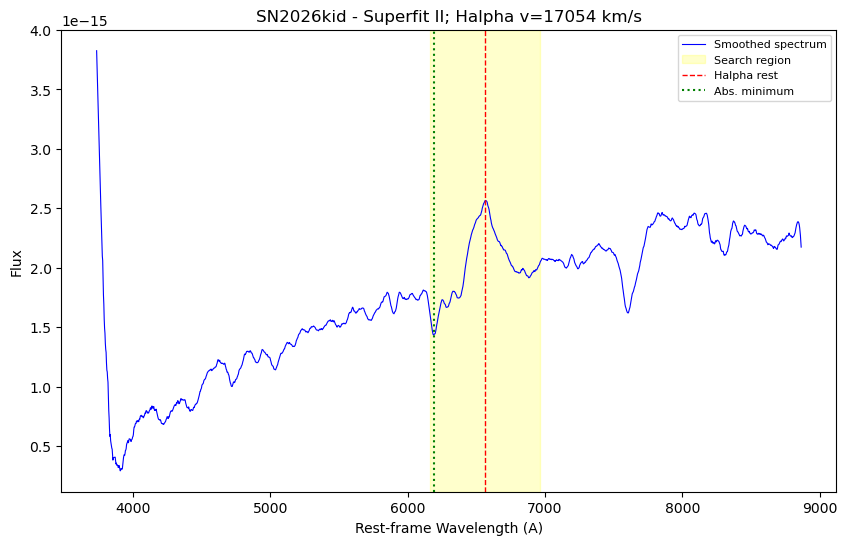

In [26]:
known_lines = {
    "Halpha": 6562.8,
    "Hbeta": 4861.3,
    "Si II": 6355.0,
    "He I": 5875.6,
    "O I": 7774.0,
    "Ca II K": 3933.7,
}

type_lower = superfit_type.lower()
if type_lower.startswith("ia"):
    line_name = "Si II"
elif type_lower.startswith("ii") or "iin" in type_lower:
    line_name = "Halpha"
elif type_lower.startswith("ib"):
    line_name = "He I"
elif type_lower.startswith("ic"):
    line_name = "O I"
else:
    line_name = "Halpha"

rest_wave = known_lines[line_name]
search_half_width = 400.0

valid = np.isfinite(wave_obs) & np.isfinite(flux_obs)
wave = wave_obs[valid]
flux = flux_obs[valid]
order = np.argsort(wave)
wave = wave[order]
flux = flux[order]

window = min(31, len(flux) // 2 * 2 - 1)
if window < 7:
    raise ValueError("Spectrum has too few points for velocity measurement")
flux_smoothed = savgol_filter(flux, window_length=window, polyorder=3)

wave_rest = wave / (1 + superfit_z)
mask = (wave_rest > rest_wave - search_half_width) & (wave_rest < rest_wave + search_half_width)
local_wave = wave_rest[mask]
local_flux = flux_smoothed[mask]

if len(local_wave) < 5:
    raise ValueError(f"No enough points near {line_name} {rest_wave:.1f} A")

blue_mask = local_wave < rest_wave
if blue_mask.sum() > 5:
    obs_abs_wave = local_wave[blue_mask][np.argmin(local_flux[blue_mask])]
else:
    obs_abs_wave = local_wave[np.argmin(local_flux)]

c_kms = 299792.458
v_exp = c_kms * (rest_wave - obs_abs_wave) / rest_wave

print(f"Spectrum file: {spec_file.name}")
print("-" * 50)
print(f"Superfit type: {superfit_type}")
print(f"Redshift:      z = {superfit_z:.5f}")
print(f"Line:          {line_name} rest lambda = {rest_wave:.1f} A")
print(f"Abs. minimum:  {obs_abs_wave:.1f} A")
print(f"v_exp:         {v_exp:.0f} km/s")
print("-" * 50)

plt.figure(figsize=(10, 6))
plt.plot(wave_rest, flux_smoothed, "b-", lw=0.8, label="Smoothed spectrum")
plt.axvspan(rest_wave - search_half_width, rest_wave + search_half_width, color="yellow", alpha=0.2, label="Search region")
plt.axvline(rest_wave, color="red", ls="--", lw=1, label=f"{line_name} rest")
plt.axvline(obs_abs_wave, color="green", ls=":", lw=1.5, label="Abs. minimum")
plt.xlabel("Rest-frame Wavelength (A)")
plt.ylabel("Flux")
plt.title(f"{target_name} - Superfit {superfit_type}; {line_name} v={v_exp:.0f} km/s")
plt.legend(fontsize=8)
plt.show()